In [19]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import h5py
import pickle 
import numpy as np 
import pyBigWig
from helpers import * 
from kerasAC.helpers.format_interpretations import * 
from scipy.stats import pearsonr, spearmanr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fold_to_seqs={} 

prof_cosine_sim_dict={}
prof_spearman_dict={} 
prof_pearson_dict={} 

count_cosine_sim_dict={} 
count_spearman_dict={} 
count_pearson_dict={} 

for fold1 in range(5):
    scores1=pickle.load(open("/srv/scratch/annashch/chrombpnet/k562_dnase/bpnet/interpret/K562.10k.DNASE.bias_corrected_bpnet_tobias.fold"+str(fold1)+".deepSHAP",'rb'))
    
    prof_shap1=scores1['profile_shap']
    count_shap1=scores1['count_shap']
    coords=list(prof_shap1.keys())
    seqs=scores1['seq']
    fold_to_seqs[fold1]=seqs 
    
    for fold2 in range(5): 
        cur_key=tuple([fold1,fold2])
        print(str(cur_key))
        prof_cosine_sim_dict[cur_key]=[]
        prof_spearman_dict[cur_key]=[]
        prof_pearson_dict[cur_key]=[] 
        
        count_cosine_sim_dict[cur_key]=[] 
        count_spearman_dict[cur_key]=[] 
        count_pearson_dict[cur_key]=[]
        
        scores2=pickle.load(open("/srv/scratch/annashch/chrombpnet/k562_dnase/bpnet/interpret/K562.10k.DNASE.bias_corrected_bpnet_tobias.fold"+str(fold2)+".deepSHAP",'rb'))
        prof_shap2=scores2['profile_shap']
        count_shap2=scores2['count_shap']
        for coord in coords: 
            cur_seq=seqs[coord]
            prof_shap1_observed=project_scores(prof_shap1[coord],cur_seq)
            prof_shap2_observed=project_scores(prof_shap2[coord],cur_seq)
            count_shap1_observed=project_scores(count_shap1[coord],cur_seq) 
            count_shap2_observed=project_scores(count_shap2[coord],cur_seq)
            #get cosine sim 
            prof_cosine_sim_dict[cur_key].append(cosine_sim(prof_shap1_observed,prof_shap2_observed))
            count_cosine_sim_dict[cur_key].append(cosine_sim(count_shap1_observed,count_shap2_observed))
            
            #get spearman 
            prof_spearman_dict[cur_key].append(spearmanr(prof_shap1_observed,prof_shap2_observed)[0])
            count_spearman_dict[cur_key].append(spearmanr(count_shap1_observed,count_shap2_observed)[0])
            
            #get pearson 
            prof_pearson_dict[cur_key].append(pearsonr(prof_shap1_observed,prof_shap2_observed)[0])
            count_pearson_dict[cur_key].append(pearsonr(count_shap1_observed,count_shap2_observed)[0])            

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(2, 0)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 0)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(4, 0)
(4, 1)
(4, 2)
(4, 3)
(4, 4)


In [3]:
class_cosine_sim_dict={}
class_spearman_dict={} 
class_pearson_dict={} 

for fold1 in range(5):
    class_shap1=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/classification/K562/interpretation/10k.DNASE.K562."+str(fold1)+".deepSHAP.interp.npz")    
    coords=list(class_shap1.keys())
    
    for fold2 in range(5): 
        
        cur_key=tuple([fold1,fold2])
        print(str(cur_key))
        
        class_cosine_sim_dict[cur_key]=[]
        class_spearman_dict[cur_key]=[]
        class_pearson_dict[cur_key]=[] 
        
        class_shap2=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/classification/K562/interpretation/10k.DNASE.K562."+str(fold2)+".deepSHAP.interp.npz")    
        for coord in coords:
            cur_seq=fold_to_seqs[fold1][coord][173:173+1000]
            class_shap2_observed=project_scores(class_shap2[coord],cur_seq)
            class_shap1_observed=project_scores(class_shap1[coord],cur_seq)
            
            #get cosine sim 
            class_cosine_sim_dict[cur_key].append(cosine_sim(class_shap1_observed,class_shap2_observed))
            
            #get spearman 
            class_spearman_dict[cur_key].append(spearmanr(class_shap1_observed,class_shap2_observed)[0])
            
            #get pearson 
            class_pearson_dict[cur_key].append(pearsonr(class_shap1_observed,class_shap2_observed)[0])            

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(2, 0)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 0)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(4, 0)
(4, 1)
(4, 2)
(4, 3)
(4, 4)


In [4]:
reg_cosine_sim_dict={}
reg_spearman_dict={} 
reg_pearson_dict={} 

for fold1 in range(5):
    reg_shap1=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/regression/K562/interpretation/10k.DNASE.K562."+str(fold1)+".deepSHAP.interp.npz")    
    coords=list(reg_shap1.keys())
    for fold2 in range(5): 
        cur_key=tuple([fold1,fold2])
        print(str(cur_key))
        reg_cosine_sim_dict[cur_key]=[]
        reg_spearman_dict[cur_key]=[]
        reg_pearson_dict[cur_key]=[] 
        
        reg_shap2=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/regression/K562/interpretation/10k.DNASE.K562."+str(fold2)+".deepSHAP.interp.npz")    
        for coord in coords: 
            cur_seq=fold_to_seqs[fold1][coord][173:173+1000]
            reg_shap2_observed=project_scores(reg_shap2[coord],cur_seq)
            reg_shap1_observed=project_scores(reg_shap1[coord],cur_seq)
            
            #get cosine sim 
            reg_cosine_sim_dict[cur_key].append(cosine_sim(reg_shap1_observed,reg_shap2_observed))
            
            #get spearman 
            reg_spearman_dict[cur_key].append(spearmanr(reg_shap1_observed,reg_shap2_observed)[0])
            
            #get pearson 
            reg_pearson_dict[cur_key].append(pearsonr(reg_shap1_observed,reg_shap2_observed)[0])            

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(2, 0)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 0)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(4, 0)
(4, 1)
(4, 2)
(4, 3)
(4, 4)


In [10]:
gkm_cosine_sim_dict={}
gkm_spearman_dict={} 
gkm_pearson_dict={} 

for fold1 in range(5):
    gkm_shap1=format_gkm_scores("/oak/stanford/groups/akundaje/projects/enzymatic_bias_correction/svm/aggregate/gkmexplain.K562."+str(fold1)+".txt")
    coords=list(gkm_shap1.keys())
    for fold2 in range(5): 
        cur_key=tuple([fold1,fold2])
        print(str(cur_key))
        gkm_cosine_sim_dict[cur_key]=[]
        gkm_spearman_dict[cur_key]=[]
        gkm_pearson_dict[cur_key]=[] 
        
        gkm_shap2=format_gkm_scores("/oak/stanford/groups/akundaje/projects/enzymatic_bias_correction/svm/aggregate/gkmexplain.K562."+str(fold2)+".txt")
        for coord in coords: 
            cur_seq=fold_to_seqs[fold1][coord][173:173+1000]
            gkm_shap2_observed=project_scores(gkm_shap2[coord],cur_seq)
            gkm_shap1_observed=project_scores(gkm_shap1[coord],cur_seq)
            
            #get cosine sim 
            gkm_cosine_sim_dict[cur_key].append(cosine_sim(gkm_shap1_observed,gkm_shap2_observed))
            
            #get spearman 
            gkm_spearman_dict[cur_key].append(spearmanr(gkm_shap1_observed,gkm_shap2_observed)[0])
            
            #get pearson 
            gkm_pearson_dict[cur_key].append(pearsonr(gkm_shap1_observed,gkm_shap2_observed)[0])            


(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(2, 0)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 0)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(4, 0)
(4, 1)
(4, 2)
(4, 3)
(4, 4)


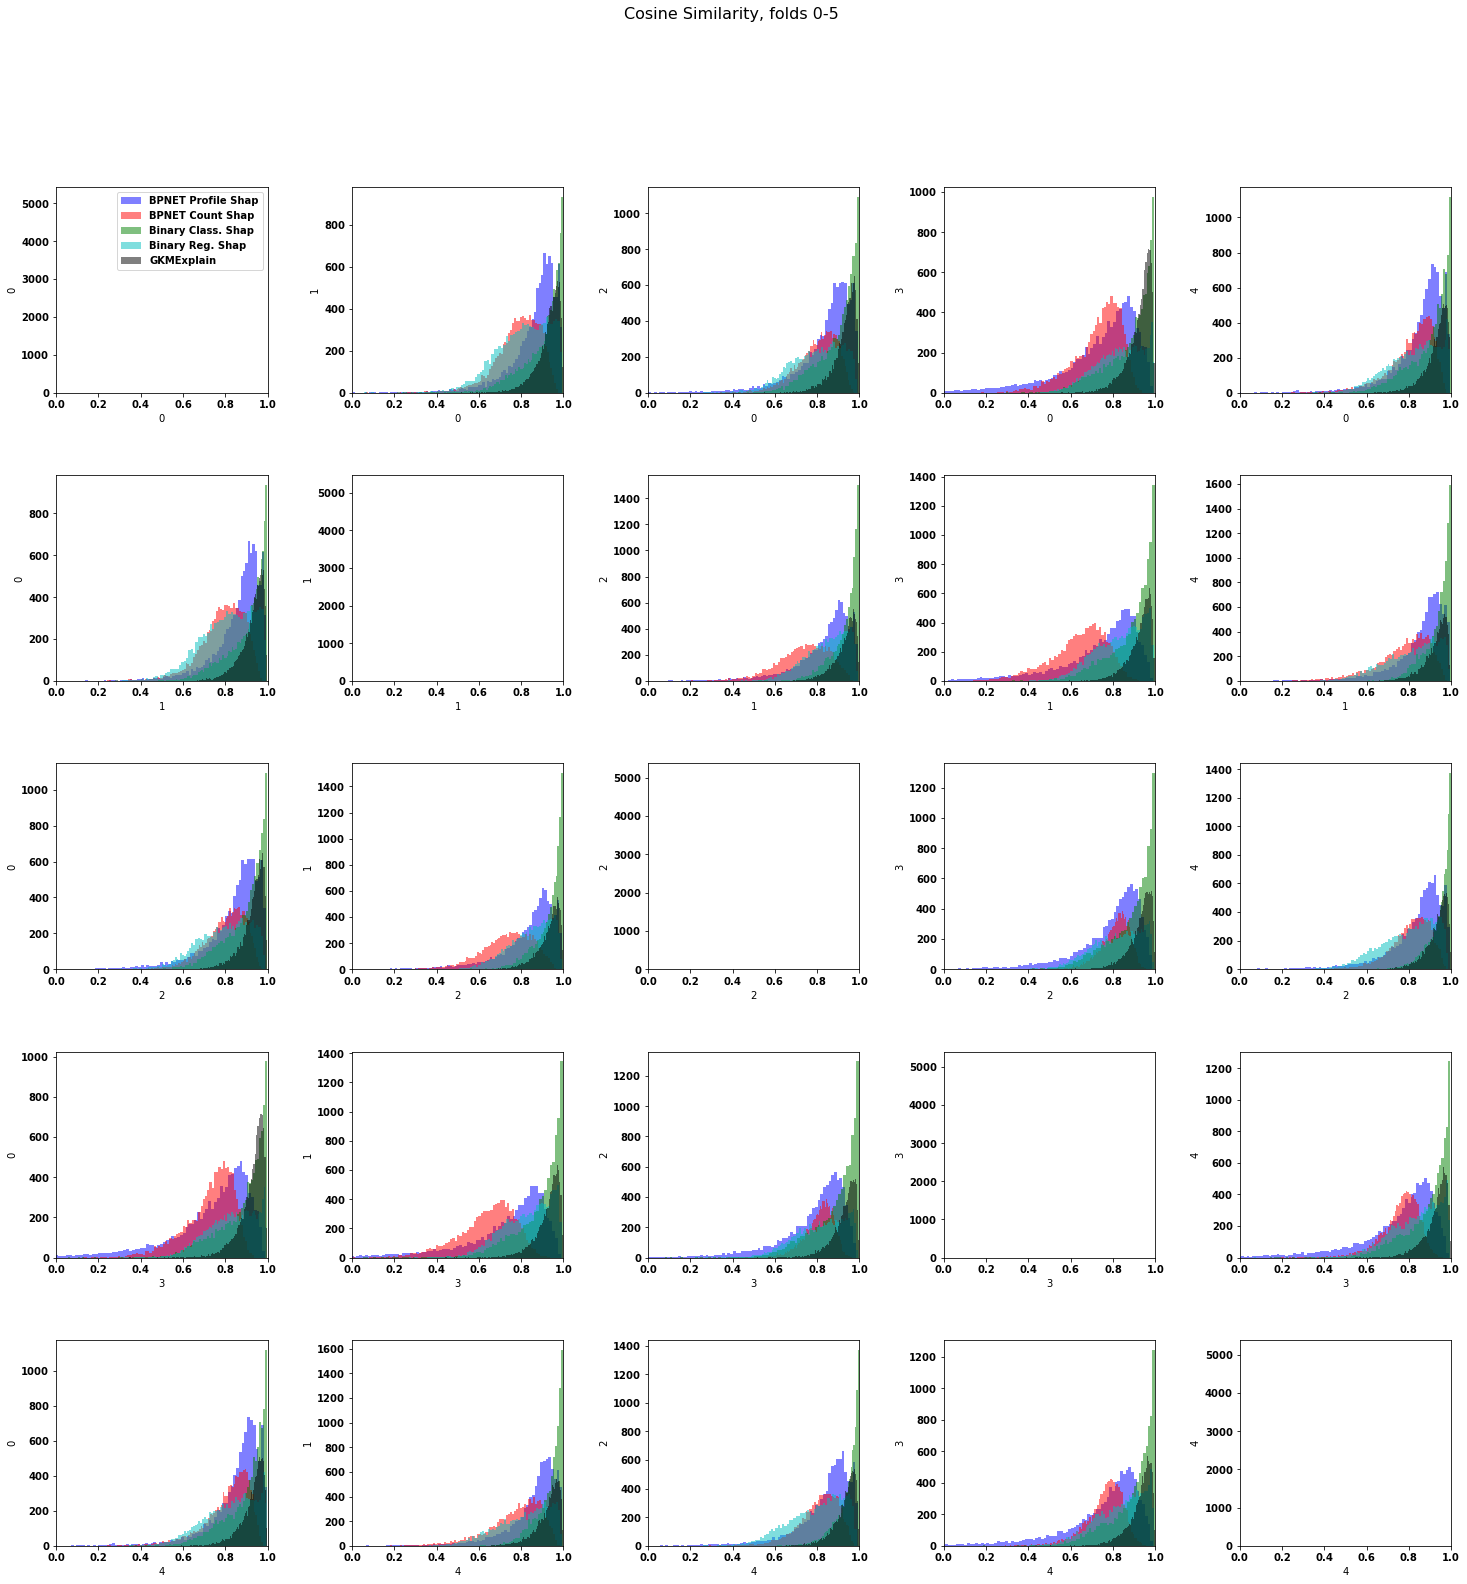

In [26]:
plt.rcParams["figure.figsize"]=25,25
fig,axes=plt.subplots(5,5)
for i in range(5):
    for j in range(5): 
        cur_key=tuple([i,j])
        axes[i,j].hist(prof_cosine_sim_dict[cur_key],bins=100,alpha=0.5,color='b',label="BPNET Profile Shap")
        axes[i,j].hist(count_cosine_sim_dict[cur_key],bins=100,alpha=0.5,color='r',label="BPNET Count Shap") 
        axes[i,j].hist(class_cosine_sim_dict[cur_key],bins=100,alpha=0.5,color='g',label="Binary Class. Shap")        
        axes[i,j].hist(reg_cosine_sim_dict[cur_key],bins=100,alpha=0.5,color='c',label="Binary Reg. Shap")         
        axes[i,j].hist(gkm_cosine_sim_dict[cur_key],bins=100,alpha=0.5,color='k',label="GKMExplain")         

        if i==0:
            if j==0: 
                axes[i,j].legend()
        axes[i,j].set_xlabel(str(i))
        axes[i,j].set_ylabel(str(j))
        axes[i,j].set_xlim(0,1)
        
fig.suptitle('Cosine Similarity, folds 0-5', fontsize=16)

plt.subplots_adjust(hspace=0.4)
plt.subplots_adjust(wspace=0.4)


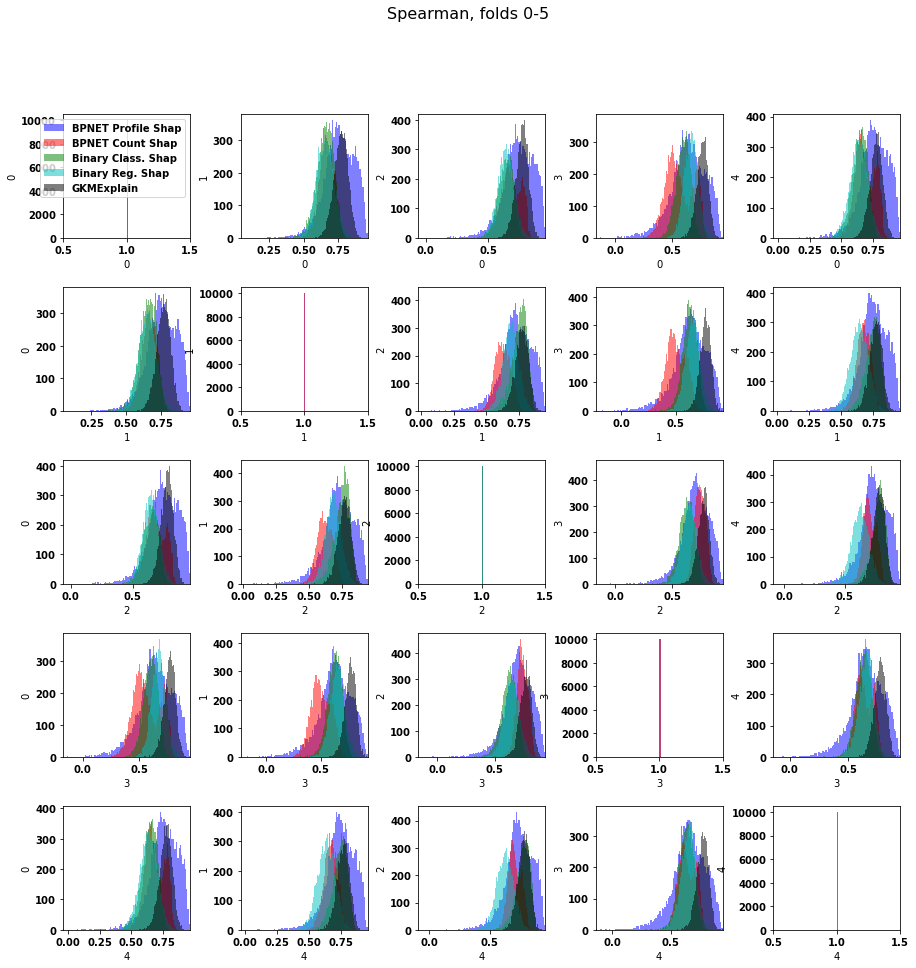

In [21]:
plt.rcParams["figure.figsize"]=15,15
fig,axes=plt.subplots(5,5)
for i in range(5):
    for j in range(5): 
        cur_key=tuple([i,j])
        axes[i,j].hist(prof_spearman_dict[cur_key],bins=100,alpha=0.5,color='b',label="BPNET Profile Shap")
        axes[i,j].hist(count_spearman_dict[cur_key],bins=100,alpha=0.5,color='r',label="BPNET Count Shap") 
        axes[i,j].hist(class_spearman_dict[cur_key],bins=100,alpha=0.5,color='g',label="Binary Class. Shap")        
        axes[i,j].hist(reg_spearman_dict[cur_key],bins=100,alpha=0.5,color='c',label="Binary Reg. Shap")         
        axes[i,j].hist(gkm_spearman_dict[cur_key],bins=100,alpha=0.5,color='k',label="GKMExplain")         

        if i==0:
            if j==0: 
                axes[i,j].legend()
        axes[i,j].set_xlabel(str(i))
        axes[i,j].set_ylabel(str(j))
fig.suptitle('Spearman, folds 0-5', fontsize=16)

plt.subplots_adjust(hspace=0.4)
plt.subplots_adjust(wspace=0.4)



In [22]:
prof_pearson_dict[tuple([0,0])][0]


1.0

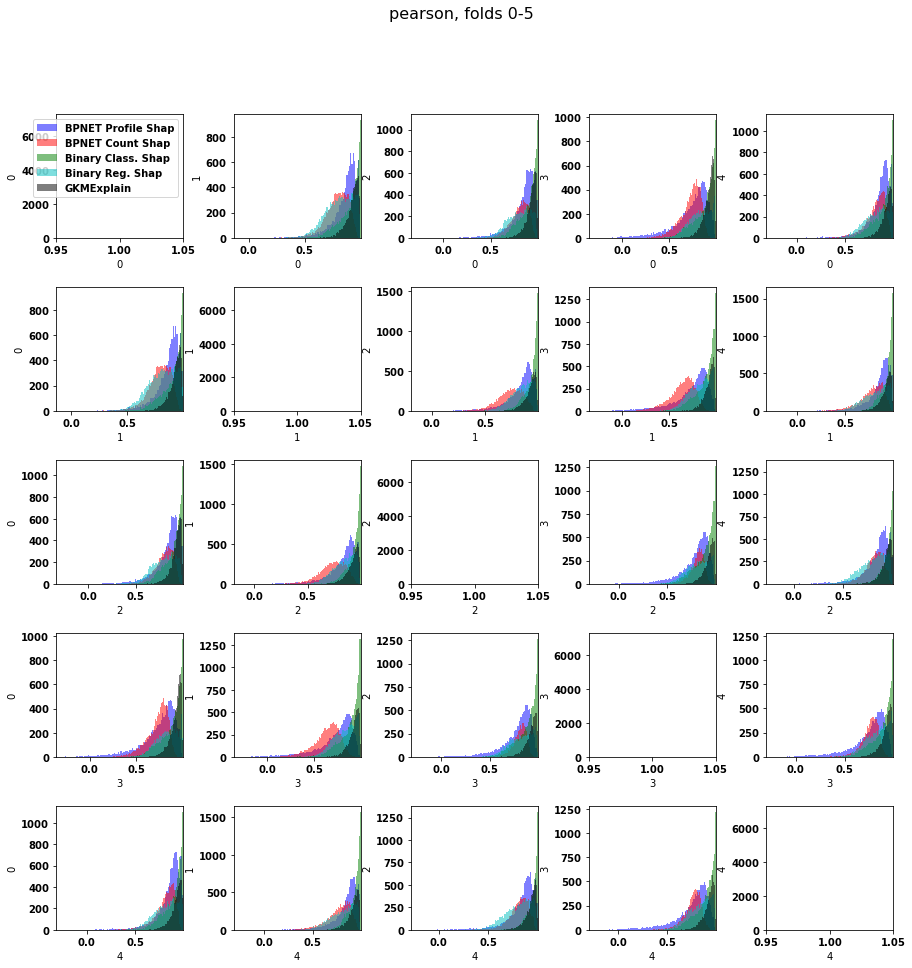

In [23]:
plt.rcParams["figure.figsize"]=15,15
fig,axes=plt.subplots(5,5)
for i in range(5):
    for j in range(5): 
        cur_key=tuple([i,j])
        axes[i,j].hist(prof_pearson_dict[cur_key],bins=100,alpha=0.5,color='b',label="BPNET Profile Shap")
        axes[i,j].hist(count_pearson_dict[cur_key],bins=100,alpha=0.5,color='r',label="BPNET Count Shap") 
        axes[i,j].hist(class_pearson_dict[cur_key],bins=100,alpha=0.5,color='g',label="Binary Class. Shap")        
        axes[i,j].hist(reg_pearson_dict[cur_key],bins=100,alpha=0.5,color='c',label="Binary Reg. Shap")         
        axes[i,j].hist(gkm_pearson_dict[cur_key],bins=100,alpha=0.5,color='k',label="GKMExplain")         

        if i==0:
            if j==0: 
                axes[i,j].legend()
        axes[i,j].set_xlabel(str(i))
        axes[i,j].set_ylabel(str(j))
fig.suptitle('pearson, folds 0-5', fontsize=16)

plt.subplots_adjust(hspace=0.4)
plt.subplots_adjust(wspace=0.4)
